## Apple Inc. (AAPL) — Sentiment Analysis & Correlation

### Overview
This notebook quantifies the relationship between financial news sentiment
and daily AAPL stock price returns. We apply VADER sentiment analysis to
news headlines, compute daily stock returns, and measure the statistical
correlation between the two using Pearson, Spearman and Kendall methods.

### Objectives
- Compare TextBlob vs VADER for financial headline sentiment analysis
- Align news publication dates to AAPL trading days
- Score each headline using VADER sentiment analysis
- Aggregate daily sentiment scores
- Compute daily stock returns
- Measure correlation between sentiment and returns
- Visualize and interpret the relationship



**We use VADER** because financial headlines are short, punchy, and often
use capitalization and punctuation for emphasis — exactly the context VADER
was designed for. TextBlob tends to classify too many financial headlines
as neutral, reducing sensitivity to meaningful sentiment shifts.

## 1. Import Libraries

In [15]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

from src.data_loader import load_news_data, filter_by_stock, load_stock_data
from src.sentiment_analyzer import (
    score_headlines_vader,
    score_headlines_textblob,
    classify_sentiment,
    align_dates,
    aggregate_daily_sentiment,
    compute_daily_returns,
    merge_sentiment_returns,
    compute_correlation
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'serif'

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Data

We load both the financial news dataset and AAPL stock price data
using our modular data loading functions from src/data_loader.py.

In [16]:
# Load news data
df_news = load_news_data('../data/raw/raw_analyst_ratings.csv')

# Filter for AAPL
aapl_news = filter_by_stock(df_news, 'AAPL')

# Load stock price data
aapl_stock = load_stock_data('../data/raw/AAPL.csv')

print(f"\nNews articles  : {len(aapl_news)}")
print(f"Stock records  : {len(aapl_stock)}")
print(f"\nNews date range  : {aapl_news['date'].min().date()} to {aapl_news['date'].max().date()}")
print(f"Stock date range : {aapl_stock['Date'].min().date()} to {aapl_stock['Date'].max().date()}")

✅ Loaded 1407328 news articles.
✅ Found 441 articles for AAPL.
✅ Loaded 3774 rows. No missing values.

News articles  : 441
Stock records  : 3774

News date range  : 2020-03-09 to 2020-06-10
Stock date range : 2009-01-02 to 2023-12-29


## 3. TextBlob vs VADER Comparison

Before proceeding with our main analysis, we demonstrate the difference
between TextBlob and VADER on a sample of real AAPL headlines to justify
our tool selection.

In [17]:
# Sample 10 headlines for comparison
sample_headlines = aapl_news['headline'].sample(10, random_state=42).tolist()

# Score with both tools
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()
comparison = []

for h in sample_headlines:
    vader_compound = sia.polarity_scores(h)['compound']
    tb_polarity = TextBlob(h).sentiment.polarity

    vader_label = classify_sentiment(vader_compound)
    tb_label = ('Positive' if tb_polarity > 0.1
                else 'Negative' if tb_polarity < -0.1
                else 'Neutral')

    comparison.append({
        'headline': h[:60] + '...' if len(h) > 60 else h,
        'vader_compound': round(vader_compound, 3),
        'vader_label': vader_label,
        'tb_polarity': round(tb_polarity, 3),
        'tb_label': tb_label,
        'agreement': '✅' if vader_label == tb_label else '❌'
    })

comp_df = pd.DataFrame(comparison)
print("=== TextBlob vs VADER Comparison ===")
print(comp_df.to_string(index=False))
print(f"\nAgreement rate: {(comp_df['agreement'] == '✅').sum()}/10")

=== TextBlob vs VADER Comparison ===
                                                       headline  vader_compound vader_label  tb_polarity tb_label agreement
Retail Pro Says Giants Like Amazon, Walmart Will Prevail Aft...           0.304    Positive       -0.350 Negative         ❌
                 Investor Movement Index Summary: February 2020           0.000     Neutral        0.000  Neutral         ✅
        Apple CEO Tim Cook Sees Remote Work Sector Accelerating           0.000     Neutral       -0.100  Neutral         ✅
                  10 Biggest Price Target Changes For Wednesday           0.000     Neutral        0.000  Neutral         ✅
Starbucks Switches To 'To Go' Model As Coronavirus Spreads, ...           0.000     Neutral        0.000  Neutral         ✅
     Bulls And Bears Of The Week: Apple, Boeing, FANGs And More           0.000     Neutral        0.500 Positive         ❌
         Benzinga's Top Upgrades, Downgrades For April 17, 2020           0.202    Positive    

## 4. Date Alignment

We normalize news publication timestamps to UTC and align them to
the nearest AAPL trading day. Articles published on weekends or
market holidays are mapped to the next available trading day.
This ensures every news article is matched to a valid stock return.

In [18]:
# Align news dates to trading days
aapl_news_aligned = align_dates(aapl_news, aapl_stock)

print(f"Total articles after alignment : {len(aapl_news_aligned)}")

# Check for unmatched articles
unmatched = aapl_news_aligned['trading_date'].isna().sum()
print(f"Unmatched articles             : {unmatched}")

print(f"\nSample of aligned dates:")
print(aapl_news_aligned[
    ['date', 'date_only', 'trading_date', 'headline']
].head(10).to_string(index=False))

Total articles after alignment : 441
Unmatched articles             : 0

Sample of aligned dates:
                     date  date_only trading_date                                                                                                                                                                            headline
2020-06-10 15:33:26+00:00 2020-06-10   2020-06-10                                                                                                               Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
2020-06-10 12:14:08+00:00 2020-06-10   2020-06-10                                                                                                                                       10 Biggest Price Target Changes For Wednesday
2020-06-10 11:53:47+00:00 2020-06-10   2020-06-10                                                                                             Benzinga Pro's Top 5 Stocks To Watch For Wed., Jun. 10, 2020: AAPL, BA

## 5. Sentiment Scoring with VADER

We apply VADER SentimentIntensityAnalyzer to each headline to compute
a compound sentiment score ranging from -1 (most negative) to +1 (most
positive). Each article is then classified as:
- **Positive** — compound score >= 0.05
- **Neutral**  — compound score between -0.05 and 0.05
- **Negative** — compound score <= -0.05

In [19]:
# Score headlines with VADER
aapl_news_scored = score_headlines_vader(aapl_news_aligned)

# Add sentiment label
aapl_news_scored['sentiment_label'] = aapl_news_scored['compound'].apply(
    classify_sentiment)

print("=== VADER Sentiment Score Statistics ===")
print(aapl_news_scored['compound'].describe())
print(f"\nSentiment Distribution:")
print(aapl_news_scored['sentiment_label'].value_counts())

aapl_news_scored[['headline', 'compound',
                   'sentiment_label']].head(10)

=== VADER Sentiment Score Statistics ===
count    441.000000
mean       0.060997
std        0.332836
min       -0.906200
25%        0.000000
50%        0.000000
75%        0.296000
max        0.936000
Name: compound, dtype: float64

Sentiment Distribution:
sentiment_label
Neutral     193
Positive    152
Negative     96
Name: count, dtype: int64


,headline,compound,sentiment_label
0,Tech Stocks And FAANGS Strong Again To Start D...,0.5574,Positive
1,10 Biggest Price Target Changes For Wednesday,0.0000,Neutral
2,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.2023,Positive
3,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.0000,Neutral
4,Apple To Let Users Trade In Their Mac Computer...,0.3818,Positive
5,Big Tech Reaches New Record Heights At The Sto...,0.0516,Positive
6,Why Apple's Stock Is Trading Higher Today,0.0000,Neutral
7,Apple Could Announce In-House Chips For Macs A...,0.0000,Neutral
8,Apple shares are trading higher despite market...,0.5472,Positive
9,"Sonos Shares Spike To Session High, Now Up 9.5...",0.4404,Positive


### 5.1 Sentiment Distribution Visualization

The charts below show the distribution of compound sentiment scores
and the breakdown of positive, neutral and negative articles.

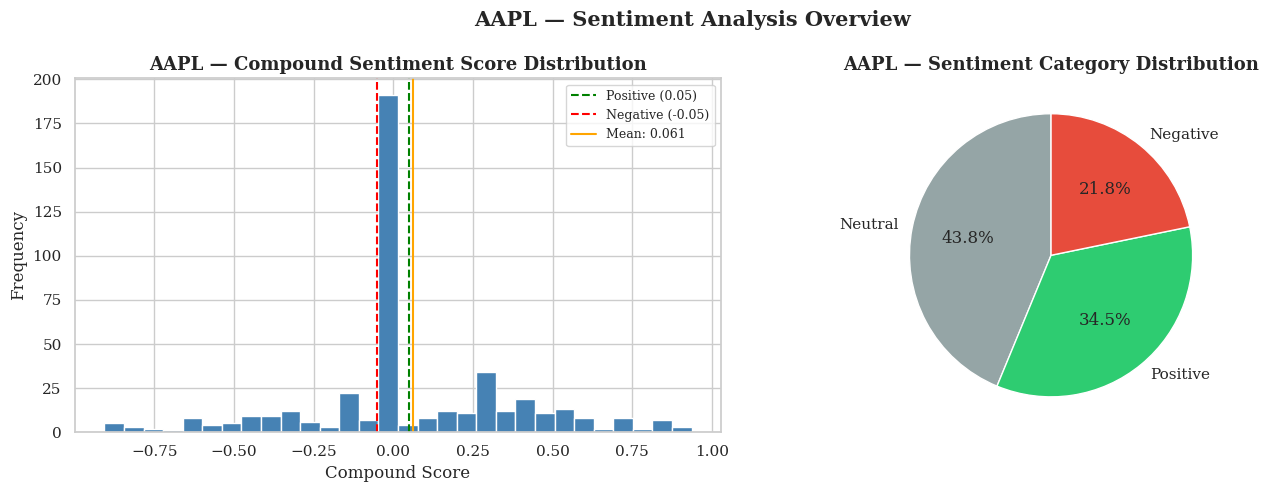

✅ Sentiment distribution plot rendered!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(aapl_news_scored['compound'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].axvline(0.05,  color='green', linestyle='--',
                label='Positive (0.05)')
axes[0].axvline(-0.05, color='red',   linestyle='--',
                label='Negative (-0.05)')
axes[0].axvline(aapl_news_scored['compound'].mean(),
                color='orange', linestyle='-',
                label=f"Mean: {aapl_news_scored['compound'].mean():.3f}")
axes[0].set_title('AAPL — Compound Sentiment Score Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Pie chart
sentiment_counts = aapl_news_scored['sentiment_label'].value_counts()
colors_pie = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=[colors_pie[s] for s in sentiment_counts.index],
    autopct='%1.1f%%', startangle=90)
axes[1].set_title('AAPL — Sentiment Category Distribution',
                  fontsize=13, fontweight='bold')

plt.suptitle('AAPL — Sentiment Analysis Overview',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Sentiment distribution plot rendered!")

## 6. Daily Sentiment Aggregation

When multiple articles are published on the same trading day, we
compute the average compound score to produce a single daily
sentiment value per stock.

In [21]:
# Aggregate to daily sentiment
daily_sentiment = aggregate_daily_sentiment(aapl_news_scored)

print(f"Total trading days with news: {len(daily_sentiment)}")
print(f"\nDaily Sentiment Summary:")
print(daily_sentiment['compound'].describe())
print(f"\nDaily Sentiment Labels:")
print(daily_sentiment['sentiment_label'].value_counts())
daily_sentiment.head(10)

Total trading days with news: 61

Daily Sentiment Summary:
count    61.000000
mean      0.056349
std       0.188480
min      -0.408683
25%      -0.025900
50%       0.054640
75%       0.166925
max       0.440400
Name: compound, dtype: float64

Daily Sentiment Labels:
sentiment_label
Positive    31
Neutral     17
Negative    13
Name: count, dtype: int64


,trading_date,compound,article_count,sentiment_label
0,2020-03-09,-0.302067,3,Negative
1,2020-03-10,-0.090787,8,Negative
2,2020-03-11,-0.023850,14,Neutral
3,2020-03-12,-0.207240,5,Negative
4,2020-03-13,-0.023191,11,Neutral
5,2020-03-16,0.028594,17,Neutral
6,2020-03-17,-0.006300,12,Neutral
7,2020-03-18,-0.077400,4,Negative
8,2020-03-19,0.191300,2,Positive
9,2020-03-20,0.434450,2,Positive


## 7. Daily Stock Returns

We compute the daily percentage change in AAPL closing prices
using the formula:

**Daily Return = (Close_t - Close_t-1) / Close_t-1 × 100**

In [22]:
# Compute daily returns
daily_returns = compute_daily_returns(aapl_stock)

print(f"Total trading days with returns: {len(daily_returns)}")
print(f"\nDaily Returns Summary:")
print(daily_returns['daily_return'].describe())
daily_returns.head(10)

Total trading days with returns: 3773

Daily Returns Summary:
count    3773.000000
mean        0.128911
std         1.801011
min       -12.864700
25%        -0.754665
50%         0.106209
75%         1.077003
max        11.980808
Name: daily_return, dtype: float64


,Date,Close,daily_return
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959
5,2009-01-09,2.716589,-2.286921
6,2009-01-12,2.659007,-2.119649
7,2009-01-13,2.630514,-1.071572
8,2009-01-14,2.559135,-2.713489
9,2009-01-15,2.500652,-2.285260
10,2009-01-16,2.469163,-1.259246


## 8. Merge Sentiment & Returns

We merge the daily sentiment scores with the daily stock returns
on the aligned trading date.

In [23]:
# Merge
merged_df = merge_sentiment_returns(daily_sentiment, daily_returns)

print(f"Total matched trading days : {len(merged_df)}")
print(f"Rows dropped during merge  : {len(daily_sentiment) - len(merged_df)}")
print(f"From : {merged_df['trading_date'].min().date()}")
print(f"To   : {merged_df['trading_date'].max().date()}")
merged_df[['trading_date', 'compound', 'sentiment_label',
           'article_count', 'daily_return']].head(10)

Total matched trading days : 61
Rows dropped during merge  : 0
From : 2020-03-09
To   : 2020-06-10


,trading_date,compound,sentiment_label,article_count,daily_return
0,2020-03-09,-0.302067,Negative,3,-7.909217
1,2020-03-10,-0.090787,Negative,8,7.202157
2,2020-03-11,-0.023850,Neutral,14,-3.473025
3,2020-03-12,-0.207240,Negative,5,-9.875496
4,2020-03-13,-0.023191,Neutral,11,11.980808
5,2020-03-16,0.028594,Neutral,17,-12.864700
6,2020-03-17,-0.006300,Neutral,12,4.397034
7,2020-03-18,-0.077400,Negative,4,-2.448005
8,2020-03-19,0.191300,Positive,2,-0.766205
9,2020-03-20,0.434450,Positive,2,-6.348547


## 9. Correlation Analysis

We compute three types of correlation coefficients between daily
sentiment scores and daily stock returns:

| Method | Best For | Outlier Sensitivity |
|--------|---------|-------------------|
| **Pearson** | Linear, normally distributed data | High |
| **Spearman** | Monotonic, non-linear data | Robust |
| **Kendall** | Small datasets, ordinal data | Most robust |

**Null Hypothesis (H₀):** There is no correlation between news sentiment
and daily stock returns.

**P-Value < 0.05:** We reject H₀ — the correlation is statistically significant.
**P-Value > 0.05:** We fail to reject H₀ — the correlation may be random noise.

In [24]:
# Compute all three correlations
corr_results = compute_correlation(merged_df)

print("=== AAPL Correlation Results ===\n")
for method, result in corr_results.items():
    sig = 'Yes ✅' if result['p'] < 0.05 else 'No ❌'
    print(f"{method.capitalize():10} | r = {result['r']:+.4f} | "
          f"p = {result['p']:.4f} | Significant: {sig}")

# Use Pearson as primary
corr = corr_results['pearson']['r']
pval = corr_results['pearson']['p']

if   abs(corr) < 0.2: strength = "Very Weak"
elif abs(corr) < 0.4: strength = "Weak"
elif abs(corr) < 0.6: strength = "Moderate"
elif abs(corr) < 0.8: strength = "Strong"
else:                  strength = "Very Strong"

direction = "Positive" if corr > 0 else "Negative"
print(f"\nPrimary (Pearson): {strength} {direction} correlation")

=== AAPL Correlation Results ===

Pearson    | r = +0.1644 | p = 0.2055 | Significant: No ❌
Spearman   | r = +0.1824 | p = 0.1594 | Significant: No ❌
Kendall    | r = +0.1274 | p = 0.1470 | Significant: No ❌

Primary (Pearson): Very Weak Positive correlation


### 9.1 Correlation Heatmap

The heatmap below shows the Pearson correlation matrix between
daily sentiment scores and daily stock returns.

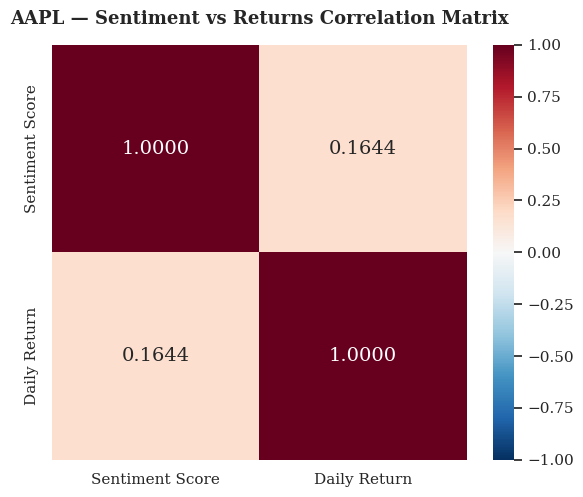

✅ Correlation heatmap rendered!


In [25]:
# Correlation heatmap
corr_matrix = merged_df[['compound', 'daily_return']].corr(
    method='pearson')
corr_matrix.index   = ['Sentiment Score', 'Daily Return']
corr_matrix.columns = ['Sentiment Score', 'Daily Return']

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, fmt='.4f',
            annot_kws={"size": 14})
plt.title('AAPL — Sentiment vs Returns Correlation Matrix',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("✅ Correlation heatmap rendered!")

### 9.2 Scatter Plot — Sentiment vs Returns

The scatter plot below shows the relationship between daily sentiment
scores and daily stock returns, annotated with the Pearson correlation
coefficient and a regression line.

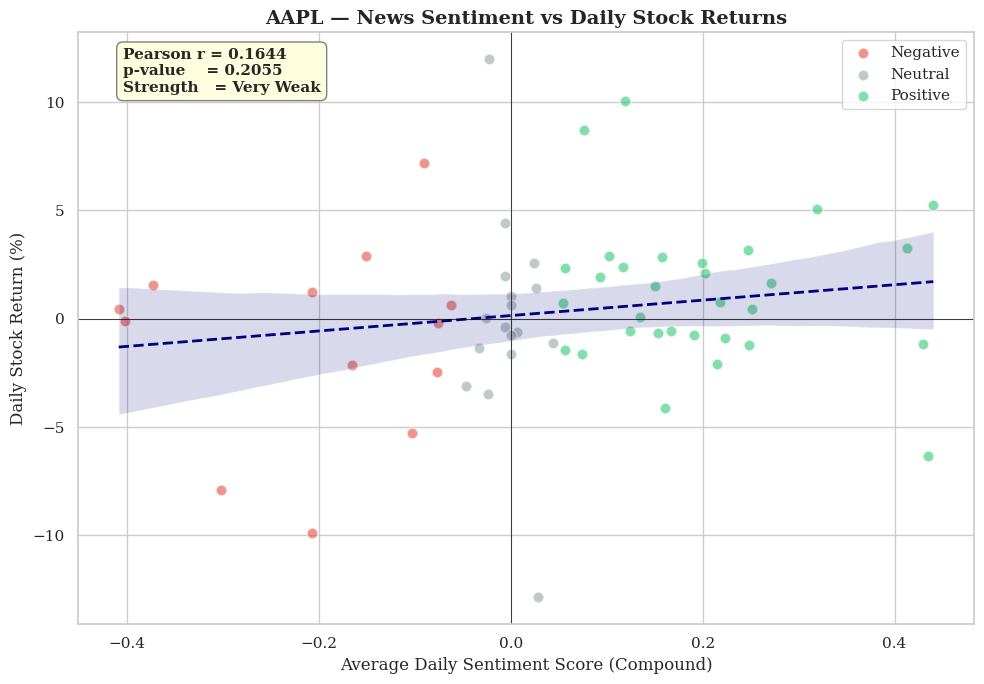

✅ Scatter plot rendered!


In [26]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}

for label, group in merged_df.groupby('sentiment_label'):
    ax.scatter(group['compound'], group['daily_return'],
               c=colors_map[label], label=label,
               alpha=0.6, s=60, edgecolors='white')

# Regression line
sns.regplot(x='compound', y='daily_return', data=merged_df,
            scatter=False, ax=ax, color='navy',
            line_kws={'linewidth': 2, 'linestyle': '--'})

# Annotate
ax.annotate(
    f'Pearson r = {corr:.4f}\np-value    = {pval:.4f}\n'
    f'Strength   = {strength}',
    xy=(0.05, 0.90), xycoords='axes fraction',
    fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='lightyellow', edgecolor='gray'))

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('AAPL — News Sentiment vs Daily Stock Returns',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Daily Sentiment Score (Compound)',
              fontsize=12)
ax.set_ylabel('Daily Stock Return (%)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Scatter plot rendered!")

### 9.3 Average Daily Return by Sentiment Category

The bar chart below shows the average daily stock return for each
sentiment category, revealing whether positive news days are
associated with higher returns.

=== Average Daily Return by Sentiment Category ===
sentiment_label  avg_return  count      std
       Negative   -1.073117     13 4.547334
        Neutral   -0.072891     17 4.812847
       Positive    1.172217     31 3.310259


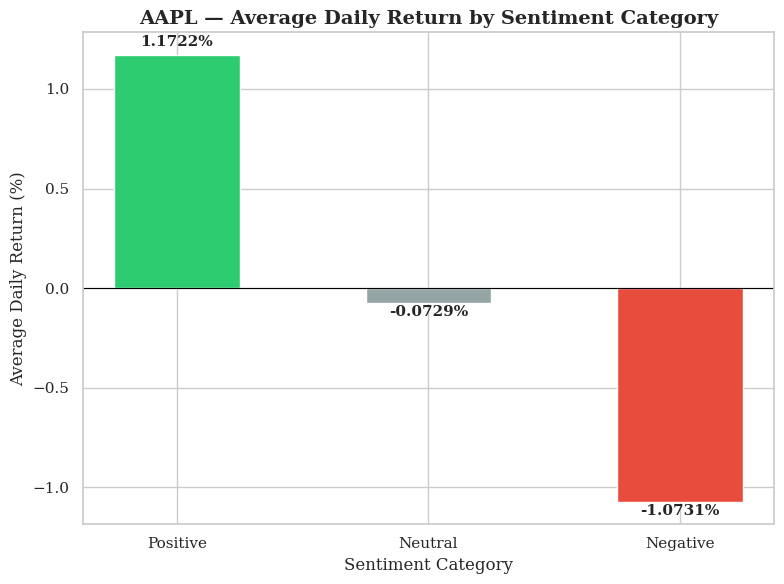

✅ Bar chart rendered!


In [27]:
# Average return per sentiment category
category_returns = merged_df.groupby(
    'sentiment_label')['daily_return'].agg(
    ['mean', 'count', 'std']).reset_index()
category_returns.columns = ['sentiment_label', 'avg_return',
                             'count', 'std']

print("=== Average Daily Return by Sentiment Category ===")
print(category_returns.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))

colors_bar = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}

# Ensure consistent order
order = ['Positive', 'Neutral', 'Negative']
cat_ordered = category_returns.set_index(
    'sentiment_label').reindex(order).reset_index()
cat_ordered = cat_ordered.dropna()

bars = ax.bar(
    cat_ordered['sentiment_label'],
    cat_ordered['avg_return'],
    color=[colors_bar[s] for s in cat_ordered['sentiment_label']],
    edgecolor='white', width=0.5)

for bar, val in zip(bars, cat_ordered['avg_return']):
    ypos = bar.get_height() + 0.03 if val >= 0 else bar.get_height() - 0.08
    ax.text(bar.get_x() + bar.get_width()/2,
            ypos,
            f'{val:.4f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('AAPL — Average Daily Return by Sentiment Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Average Daily Return (%)', fontsize=12)
plt.tight_layout()
plt.show()
print("✅ Bar chart rendered!")

### 9.4 Sentiment Score & Stock Return Over Time

The time series chart shows how daily sentiment scores and daily
stock returns move together over the analysis period.

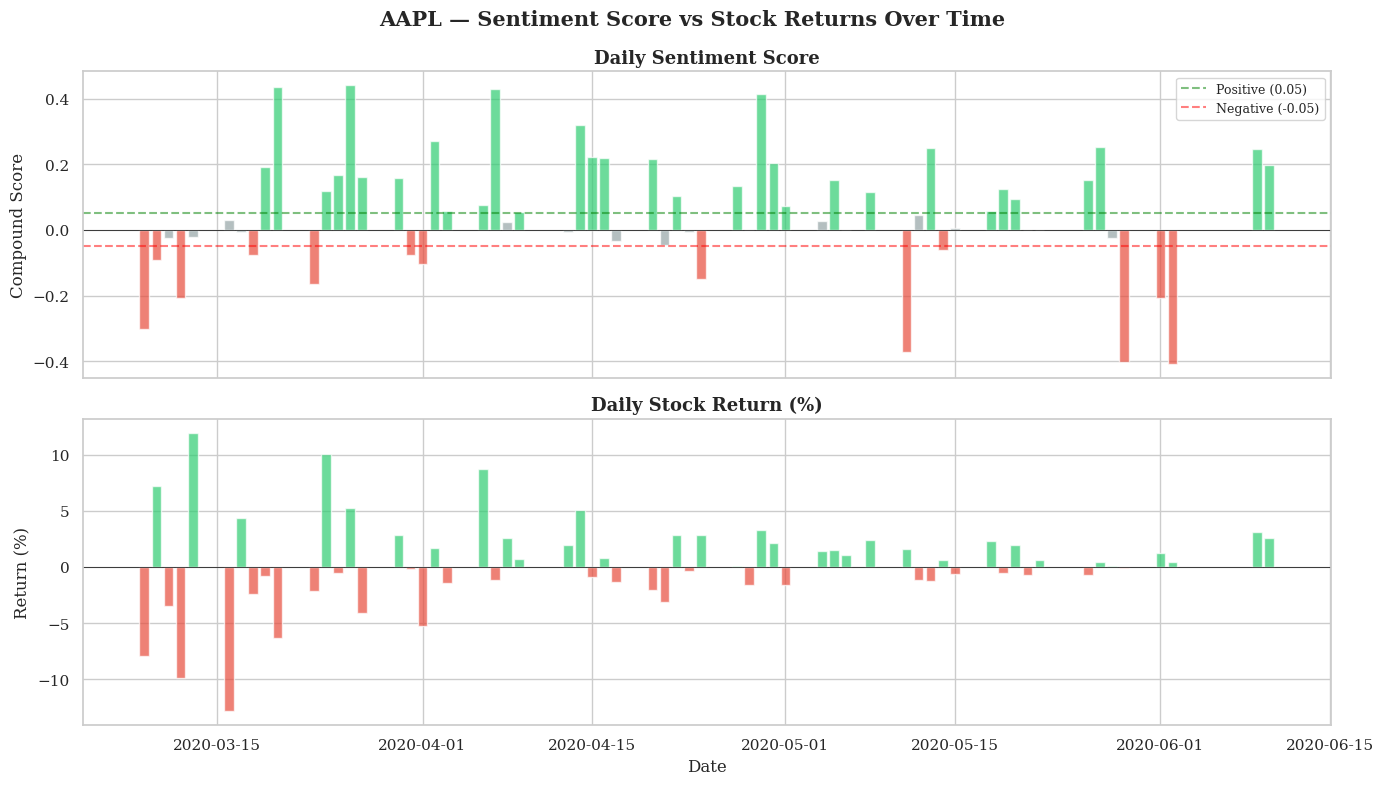

✅ Time series plot rendered!


In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Sentiment over time
axes[0].bar(merged_df['trading_date'], merged_df['compound'],
            color=['#2ecc71' if v >= 0.05
                   else '#e74c3c' if v <= -0.05
                   else '#95a5a6'
                   for v in merged_df['compound']],
            alpha=0.7)
axes[0].axhline(0.05,  color='green', linestyle='--',
                alpha=0.5, label='Positive (0.05)')
axes[0].axhline(-0.05, color='red',   linestyle='--',
                alpha=0.5, label='Negative (-0.05)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Daily Sentiment Score',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Compound Score')
axes[0].legend(fontsize=9)

# Returns over time
axes[1].bar(merged_df['trading_date'], merged_df['daily_return'],
            color=['#2ecc71' if v >= 0 else '#e74c3c'
                   for v in merged_df['daily_return']],
            alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Daily Stock Return (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Return (%)')
axes[1].set_xlabel('Date')

plt.suptitle('AAPL — Sentiment Score vs Stock Returns Over Time',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series plot rendered!")

## 10. Key Findings & Summary

In [29]:
# Ensure cat_ordered is always available
order = ['Positive', 'Neutral', 'Negative']
cat_ordered = category_returns.set_index(
    'sentiment_label').reindex(order).reset_index().dropna()
print("=" * 55)
print("   AAPL SENTIMENT CORRELATION — KEY FINDINGS")
print("=" * 55)

print(f"""
📰 ANALYSIS OVERVIEW
- Total articles analyzed     : {len(aapl_news_scored)}
- Trading days matched        : {len(merged_df)}
- Date range                  : {merged_df['trading_date'].min().date()} to {merged_df['trading_date'].max().date()}

😊 SENTIMENT SUMMARY
- Average compound score      : {aapl_news_scored['compound'].mean():.4f}
- Positive articles           : {(aapl_news_scored['sentiment_label'] == 'Positive').sum()}
- Neutral articles            : {(aapl_news_scored['sentiment_label'] == 'Neutral').sum()}
- Negative articles           : {(aapl_news_scored['sentiment_label'] == 'Negative').sum()}

📈 CORRELATION RESULTS
- Pearson  r = {corr_results['pearson']['r']:+.4f}  p = {corr_results['pearson']['p']:.4f}  {'✅ Significant' if corr_results['pearson']['p'] < 0.05 else '❌ Not Significant'}
- Spearman r = {corr_results['spearman']['r']:+.4f}  p = {corr_results['spearman']['p']:.4f}  {'✅ Significant' if corr_results['spearman']['p'] < 0.05 else '❌ Not Significant'}
- Kendall  r = {corr_results['kendall']['r']:+.4f}  p = {corr_results['kendall']['p']:.4f}  {'✅ Significant' if corr_results['kendall']['p'] < 0.05 else '❌ Not Significant'}

- Pearson Strength            : {strength}
- Pearson Direction           : {direction}

📊 AVERAGE RETURNS BY SENTIMENT
""")
for _, row in cat_ordered.iterrows():
    print(f"  {row['sentiment_label']:10} : {row['avg_return']:.4f}% "
          f"(n={int(row['count'])})")

print("\n" + "=" * 55)

   AAPL SENTIMENT CORRELATION — KEY FINDINGS

📰 ANALYSIS OVERVIEW
- Total articles analyzed     : 441
- Trading days matched        : 61
- Date range                  : 2020-03-09 to 2020-06-10

😊 SENTIMENT SUMMARY
- Average compound score      : 0.0610
- Positive articles           : 152
- Neutral articles            : 193
- Negative articles           : 96

📈 CORRELATION RESULTS
- Pearson  r = +0.1644  p = 0.2055  ❌ Not Significant
- Spearman r = +0.1824  p = 0.1594  ❌ Not Significant
- Kendall  r = +0.1274  p = 0.1470  ❌ Not Significant

- Pearson Strength            : Very Weak
- Pearson Direction           : Positive

📊 AVERAGE RETURNS BY SENTIMENT

  Positive   : 1.1722% (n=31)
  Neutral    : -0.0729% (n=17)
  Negative   : -1.0731% (n=13)



## 11. Interpretation & Conclusion

**Correlation Interpretation:**
All three correlation methods consistently show a **very weak positive relationship** between AAPL news sentiment and same-day stock returns, with a Pearson coefficient of +0.1644 (p=0.2055). The correlation is **not statistically significant**, meaning we cannot confidently reject the null hypothesis that there is no relationship between sentiment and returns for AAPL during this period.

**Sentiment Category Analysis:**
Despite the weak correlation, the bar chart reveals a compelling pattern — positive sentiment days averaged **+1.17% returns**, neutral days averaged **-0.07%**, and negative sentiment days averaged **-1.07%**. This monotonic decrease from positive to negative categories suggests a directional relationship even if the overall linear correlation is weak. The pattern is consistent with the investment hypothesis that positive news days tend to coincide with stronger stock performance.

**Limitations:**
- The analysis covers only **61 matched trading days** (March–June 2020), a period dominated by COVID-19 volatility which may distort the true sentiment-return relationship
- The **lack of statistical significance** (p=0.2055) suggests the sample size is too small to draw strong conclusions
- **Lag effects** may mean the market reacts to news the following day rather than the same day
- **Confounding factors** such as broad market movements, Fed stimulus announcements, and supply chain news affected AAPL independently of headline sentiment